#### Load and inspect all four files:

In [ ]:
import pandas as pd
from pathlib import Path
from langdetect import detect, LangDetectException

# Paths relative to notebook location
raw_dir = Path("../data/raw")

#COMPANY = "amd" # "amd" / "nvidia"

companies = {
    "AMD": "glassdoor_AMD",
    "NVIDIA": "glassdoor_NVIDIA",
    "HP": "glassdoor_HP",
    "DELL": "glassdoor_DELL",
}

YEAR_RANGE = (2019, 2024)

In [2]:
for company_name, file_prefix in companies.items():
    print(f"\n{'='*60}")
    print(f"  Verarbeite: {company_name}")
    print(f"{'='*60}")

    # Lade alle 5 Sterne-Dateien
    dfs = []
    for star in [1, 2, 3, 4, 5]:
        path = raw_dir / f"{file_prefix}_rating{star}.xlsx"
        if not path.exists():
            print(f"  WARNUNG: {path.name} nicht gefunden, überspringe.")
            continue
        df = pd.read_excel(path)
        df["star_filter"] = star
        if star <= 2:
            df["sentiment_label"] = "negative"
        elif star == 3:
            df["sentiment_label"] = "neutral"
        else:
            df["sentiment_label"] = "positive"
        dfs.append(df)
        print(f"  Rating {star}: {len(df)} Reviews")

    df_all = pd.concat(dfs, ignore_index=True)

    # Helpful_count droppen falls vorhanden
    if "helpful_count" in df_all.columns:
        df_all = df_all.drop(columns=["helpful_count"])
    if "source_url" in df_all.columns:
        df_all = df_all.drop(columns=["source_url"])

    # Datum parsen
    df_all["review_date_parsed"] = pd.to_datetime(
        df_all["review_date"], format="mixed",
        dayfirst=False, errors="coerce"
    )
    bad_dates = df_all["review_date_parsed"].isna().sum()
    if bad_dates > 0:
        print(f"  WARNUNG: {bad_dates} nicht-parsbare Daten")

    df_all["year"] = df_all["review_date_parsed"].dt.year
    df_all["quarter"] = df_all["review_date_parsed"].dt.quarter

    # Zeitraum filtern
    df_filtered = df_all[df_all["year"].between(*YEAR_RANGE)].copy()
    print(f"  Nach Zeitfilter: {len(df_filtered)} Reviews")

    # Deduplizieren
    before = len(df_filtered)
    df_filtered = df_filtered.drop_duplicates(
        subset=["pros", "cons", "review_date"], keep="first"
    )
    print(f"  Duplikate entfernt: {before - len(df_filtered)}")

    # Textfelder vorbereiten
    for col in ["headline", "pros", "cons"]:
        if col in df_filtered.columns:
            df_filtered[col] = df_filtered[col].fillna("")

    df_filtered["review_text"] = (
        df_filtered.get("headline", "").astype(str) + ". Pros: " +
        df_filtered["pros"].astype(str) + ". Cons: " +
        df_filtered["cons"].astype(str)
    )

    # Sprachfilter
    def safe_detect(text):
        try:
            return detect(str(text))
        except LangDetectException:
            return "unknown"

    df_filtered["language"] = df_filtered["review_text"].apply(safe_detect)
    non_english = (df_filtered["language"] != "en").sum()
    df_filtered = df_filtered[df_filtered["language"] == "en"].copy()
    print(f"  Nicht-englische Reviews entfernt: {non_english}")

    # Spalten auswählen und speichern
    output_cols = [
        "overall_stars", "review_date_parsed", "year", "quarter",
        "headline", "job_title", "employment_status", "location",
        "pros", "cons", "review_text", "sentiment_label", "star_filter"
    ]
    available_cols = [c for c in output_cols if c in df_filtered.columns]
    df_final = df_filtered[available_cols].rename(
        columns={"review_date_parsed": "date"}
    )
    df_final = df_final.sort_values(["year", "date"]).reset_index(drop=True)

    output_path = f"../data/interim/{company_name.lower()}_clean.csv"
    df_final.to_csv(output_path, index=False)

    print(f"\n  FERTIG: {len(df_final)} Reviews gespeichert")
    print(f"  → {output_path}")
    print(f"\n  Jahr × Sentiment:")
    print(pd.crosstab(df_final["year"], df_final["sentiment_label"]))



  Verarbeite: AMD
  Rating 1: 110 Reviews
  Rating 2: 120 Reviews
  Rating 3: 425 Reviews
  Rating 4: 1220 Reviews
  Rating 5: 1035 Reviews
  Nach Zeitfilter: 2512 Reviews
  Duplikate entfernt: 0
  Nicht-englische Reviews entfernt: 0

  FERTIG: 2512 Reviews gespeichert
  → ../data/interim/amd_clean.csv

  Jahr × Sentiment:
sentiment_label  negative  neutral  positive
year                                        
2019                    8       18       109
2020                   19       28       139
2021                   29       45       352
2022                   26       63       433
2023                   37       72       458
2024                   52      116       508

  Verarbeite: NVIDIA
  Rating 1: 45 Reviews
  Rating 2: 40 Reviews
  Rating 3: 120 Reviews
  Rating 4: 510 Reviews
  Rating 5: 1790 Reviews
  Nach Zeitfilter: 2197 Reviews
  Duplikate entfernt: 0
  Nicht-englische Reviews entfernt: 1

  FERTIG: 2196 Reviews gespeichert
  → ../data/interim/nvidia_clean.csv

  Jah

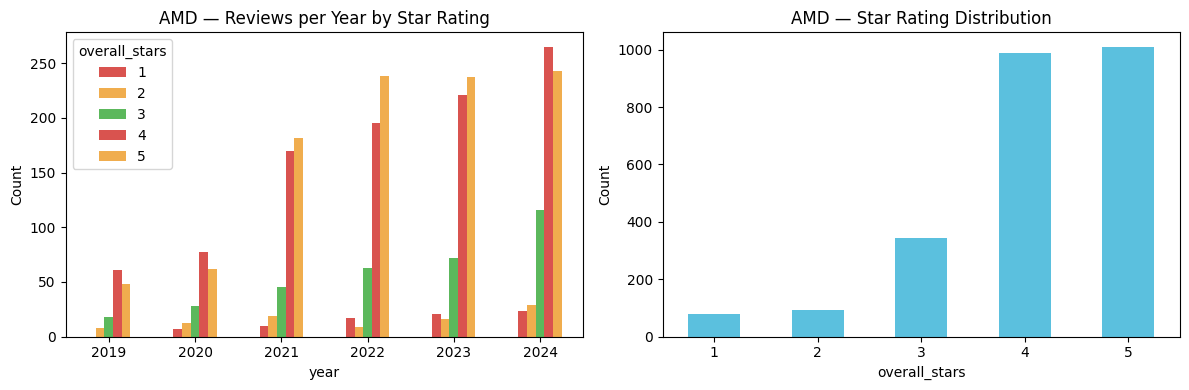

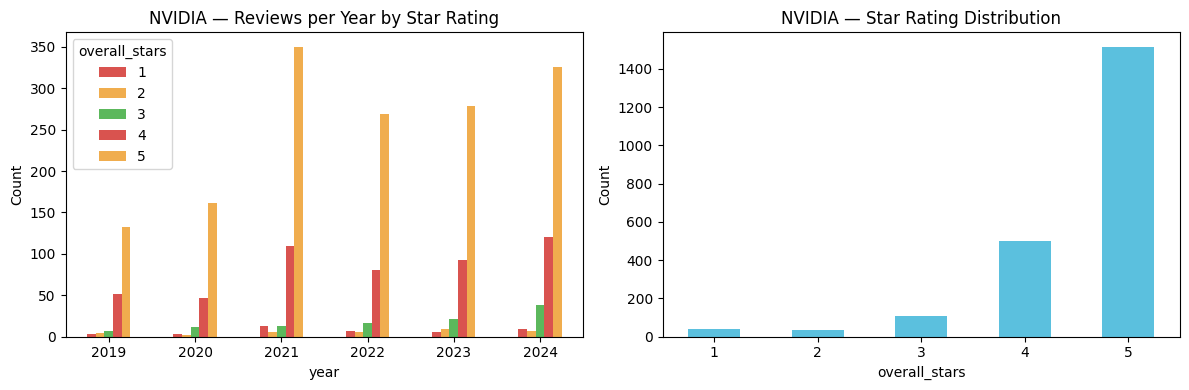

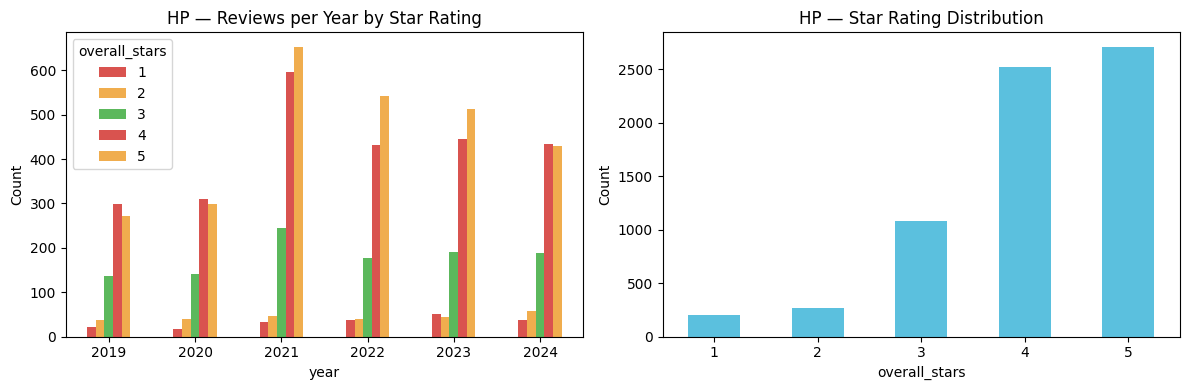

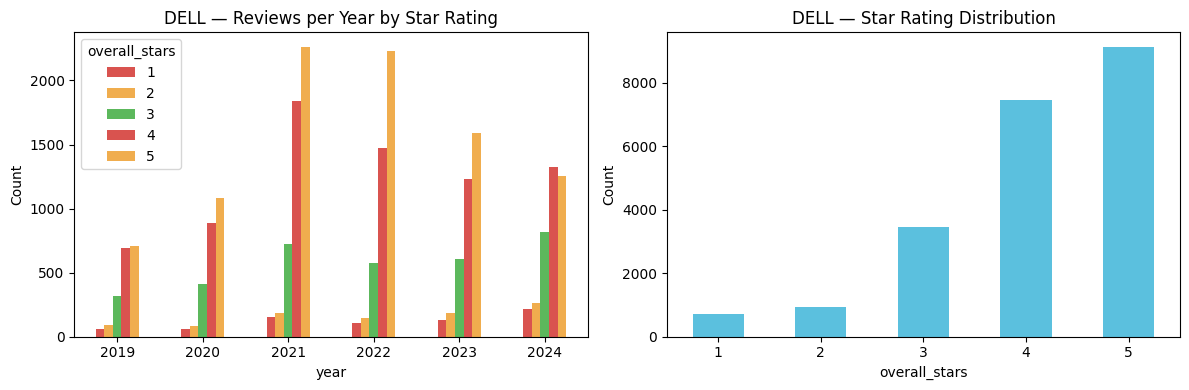

In [3]:
import matplotlib.pyplot as plt

for company_name in companies.keys():
    csv_path = f"../data/interim/{company_name.lower()}_clean.csv"
    df_vis = pd.read_csv(csv_path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ct = pd.crosstab(df_vis["year"], df_vis["overall_stars"])
    ct.plot(kind="bar", ax=axes[0], color=["#d9534f", "#f0ad4e", "#5cb85c"])
    axes[0].set_title(f"{company_name} — Reviews per Year by Star Rating")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=0)

    df_vis["overall_stars"].value_counts().sort_index().plot(
        kind="bar", ax=axes[1], color="#5bc0de"
    )
    axes[1].set_title(f"{company_name} — Star Rating Distribution")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(f"../results/{company_name.lower()}_sample_overview.png",
                dpi=150, bbox_inches="tight")
    plt.show()

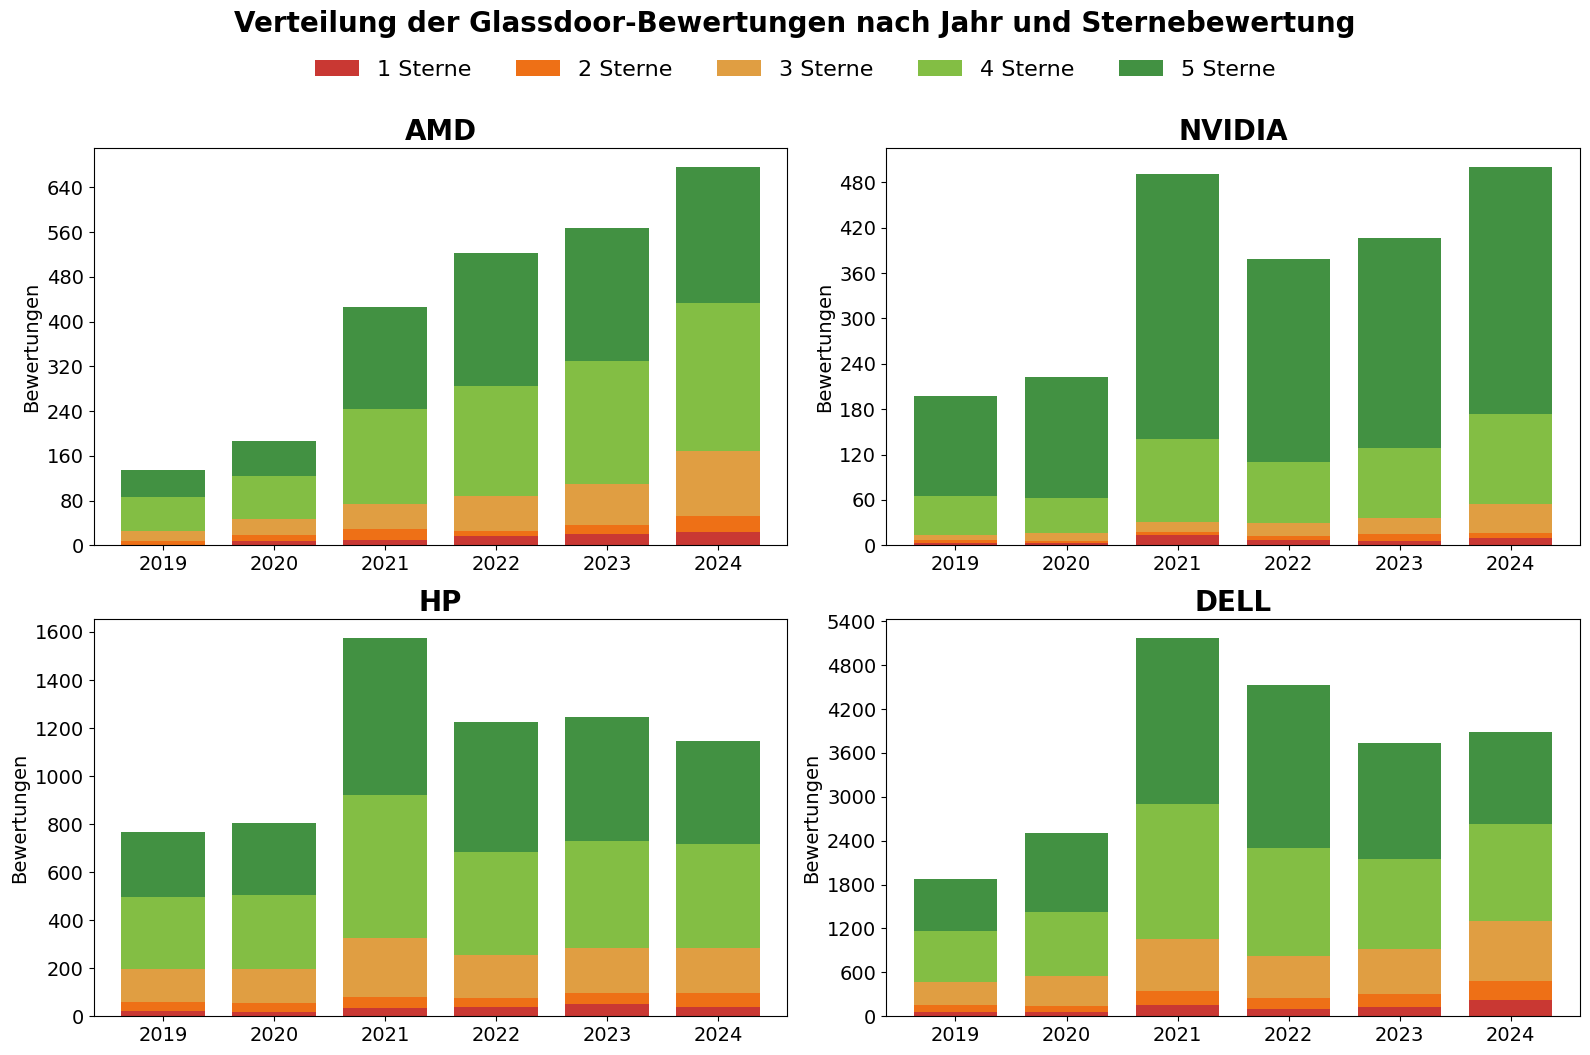

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Farbpalette für 5 Sterne
star_colors = {
    1: "#c93833",  # rot
    2: "#ee7016",  # orange-rot
    3: "#e09e42",  # orange
    4: "#83be44",  # hellgrün
    5: "#429142",  # grün
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, company_name in enumerate(companies.keys()):
    csv_path = f"../data/interim/{company_name.lower()}_clean.csv"
    df_vis = pd.read_csv(csv_path)

    ax = axes[i]

    # Kreuztabelle: Jahr × Sterne
    ct = pd.crosstab(df_vis["year"], df_vis["star_filter"])
    ct = ct.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
    ct.columns = [f"{s} Sterne" for s in ct.columns]

    colors = [star_colors[s] for s in [1, 2, 3, 4, 5]]
    ct.plot(kind="bar", stacked=True, ax=ax, color=colors,
            width=0.75, legend=(i == 0))

    ax.set_title(f"{company_name}", fontsize=20, fontweight="bold")
    ax.set_ylabel("Bewertungen", fontsize=14)
    ax.set_xlabel("", fontsize=16)
    ax.tick_params(axis="x", rotation=0, labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Gemeinsame Legende nur einmal oben
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
fig.legend(handles, labels, loc="upper center",
           ncol=5, bbox_to_anchor=(0.5, 1.02),
           fontsize=16, frameon=False)

plt.suptitle("Verteilung der Glassdoor-Bewertungen nach Jahr und Sternebewertung",
             fontsize=20, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("../results/alle_firmen_reviewverteilung.png",
            dpi=300, bbox_inches="tight")
plt.savefig("../results/latex/fig_reviewverteilung.pdf",
            dpi=300, bbox_inches="tight")
plt.show()
 

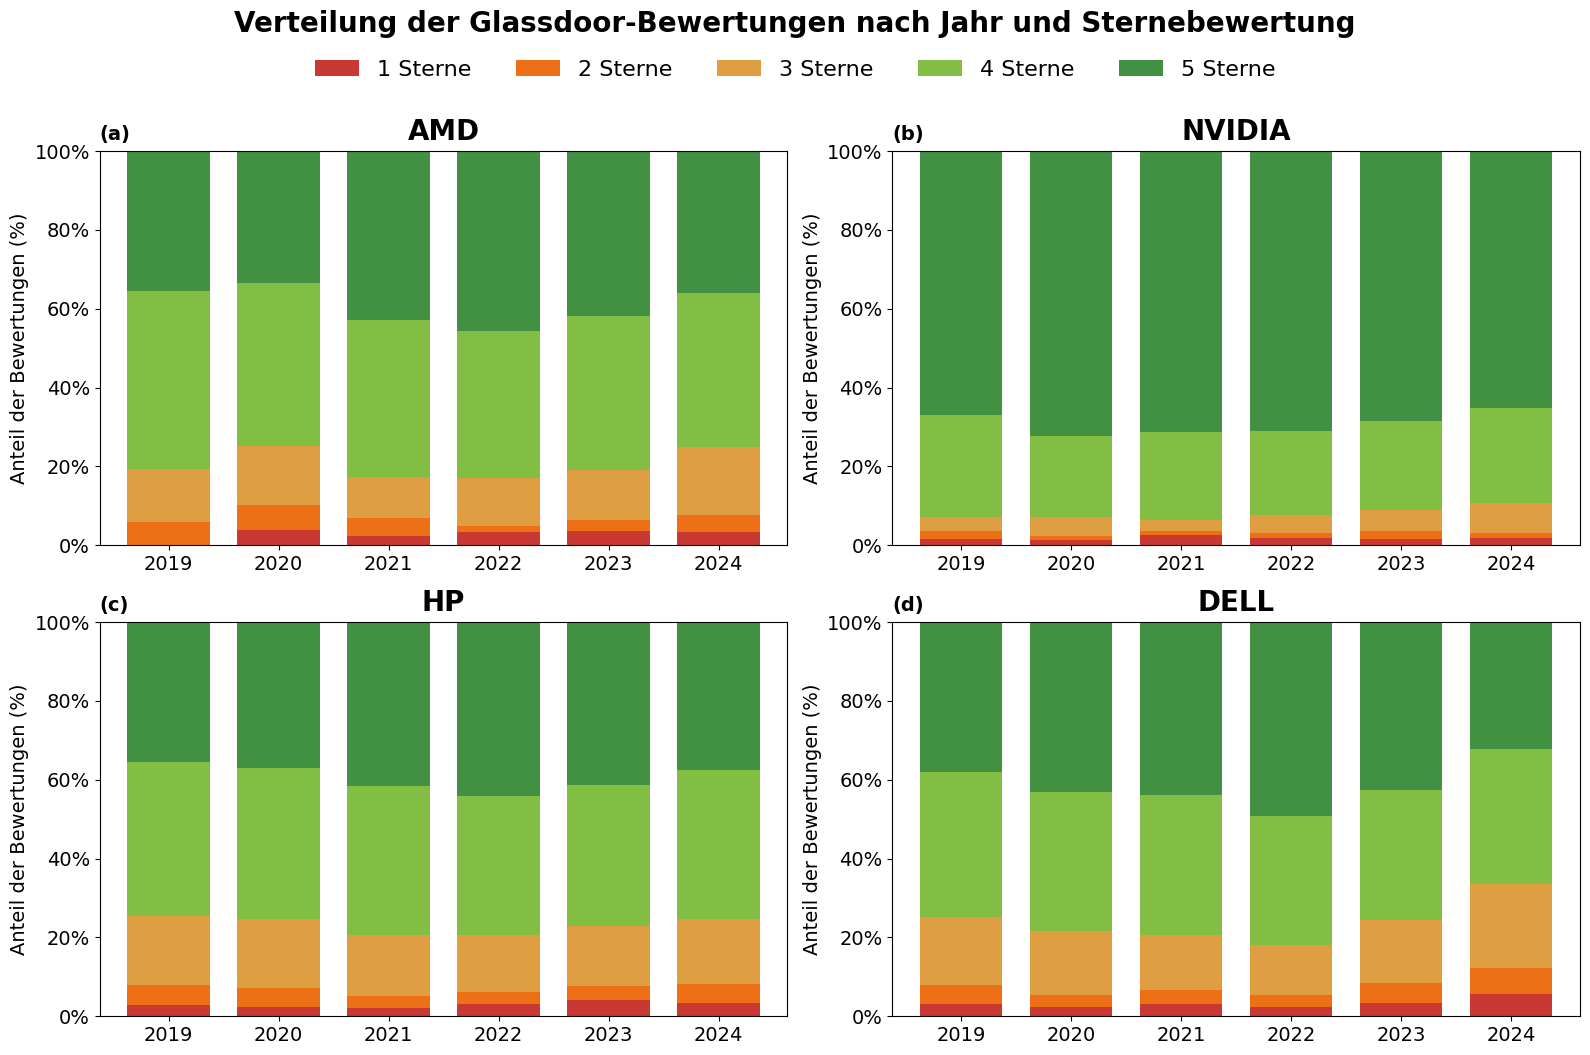

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Farbpalette für 5 Sterne
star_colors = {
    1: "#c93833",  # rot
    2: "#ee7016",  # orange-rot
    3: "#e09e42",  # orange
    4: "#83be44",  # hellgrün
    5: "#429142",  # grün
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, company_name in enumerate(companies.keys()):
    csv_path = f"../data/interim/{company_name.lower()}_clean.csv"
    df_vis = pd.read_csv(csv_path)

    ax = axes[i]

    # Kreuztabelle: Jahr × Sterne
    ct = pd.crosstab(df_vis["year"], df_vis["star_filter"])

    # Sicherstellen, dass alle Sterne 1–5 vorhanden sind
    ct = ct.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)

    # In Prozent umwandeln:
    # Jede Zeile (= jedes Jahr) summiert sich auf 100 %
    ct = ct.div(ct.sum(axis=1), axis=0) * 100

    # Spaltennamen
    ct.columns = [f"{s} Sterne" for s in ct.columns]

    colors = [star_colors[s] for s in [1, 2, 3, 4, 5]]

    ct.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=colors,
        width=0.75,
        legend=(i == 0)
    )

    ax.set_title(
        f"{company_name}",
        fontsize=20,
        fontweight="bold"
    )

    ax.set_ylabel("Anteil der Bewertungen (%)", fontsize=14)
    ax.set_xlabel("", fontsize=16)

    ax.tick_params(
        axis="x",
        rotation=0,
        labelsize=14
    )

    ax.tick_params(
        axis="y",
        labelsize=14
    )

    # Y-Achse immer von 0 bis 100 %
    ax.set_ylim(0, 100)

    # Y-Achse in Prozent formatieren
    ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Gemeinsame Legende nur einmal oben
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()

# Insert subplot labels (a), (b), (c), (d)
for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.set_title(label, loc='left', fontsize=14, fontweight='bold', pad=8)


fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=16,
    frameon=False
)

plt.suptitle(
    "Verteilung der Glassdoor-Bewertungen nach Jahr und Sternebewertung",
    fontsize=20,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()

plt.savefig(
    "../results/alle_firmen_reviewverteilung_100percent.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/latex/fig_reviewverteilung_100percent.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()